# Day 1 — From-Scratch Linear Regression (NumPy)

**Goal.** Implement linear regression two different ways, from scratch, using only NumPy:

1. **Gradient descent** — iteratively nudge θ in the direction of the negative gradient until the cost stops decreasing.
2. **Normal equation** — solve `XᵀX θ = Xᵀy` analytically in one step.

Both should land on essentially the same θ, and both should match `sklearn.LinearRegression` (which we'll use only as a correctness oracle, never inside our model).

The math derivation for the gradient lives in `README.md`. This notebook is the implementation half — every line of code should map back to a step of that derivation.

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Reproducibility — any randomness (train/test split, init) should be deterministic.
RNG = np.random.default_rng(seed=42)

## 1. Load the data and look at it

`load_diabetes` gives us:

- **442 patients** (rows)
- **10 features** per patient — already mean-centered and scaled by sklearn, which saves us a preprocessing step
- **1 target** — a quantitative measure of disease progression one year after baseline

Before any modelling, we should *look* at the shapes and a few values. "Trust nothing, print everything" is a good early-stage habit.

In [2]:
data = load_diabetes()
X_raw = data.data      # shape (442, 10)
y     = data.target    # shape (442,)

print('X_raw shape :', X_raw.shape)
print('y shape     :', y.shape)
print('feature names:', data.feature_names)
print()
print('First row of X (one patient):')
print(X_raw[0])
print()
print('First 5 targets:', y[:5])
print('Target stats — min: {:.1f}  mean: {:.1f}  max: {:.1f}'.format(y.min(), y.mean(), y.max()))

X_raw shape : (442, 10)
y shape     : (442,)
feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First row of X (one patient):
[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]

First 5 targets: [151.  75. 141. 206. 135.]
Target stats — min: 25.0  mean: 152.1  max: 346.0


Two things to notice:

1. **The features are tiny.** sklearn's diabetes dataset is pre-standardised so each column has mean 0 and (roughly) unit variance. That means gradient descent will behave well without us doing extra preprocessing.
2. **The target is on a totally different scale** (roughly 25–350). The model has to learn θ values large enough to produce predictions in that range from features that are ~±0.1.

## 2. Add the bias column

Recall the math setup: we want predictions of the form

$$\hat{y} = \theta_0 + \theta_1 x_1 + \dots + \theta_{10} x_{10}$$

The standard trick: prepend a column of 1s to `X` so that θ₀ has its own dummy feature. Then a single matrix-vector product `Xθ` produces all 442 predictions at once.

After this step `X` has shape `(442, 11)` — 10 features + 1 bias column.

In [3]:
m = X_raw.shape[0]                       # number of training examples
bias_col = np.ones((m, 1))               # shape (442, 1)
X = np.hstack([bias_col, X_raw])         # shape (442, 11)

print('X shape after bias column:', X.shape)
print('First row (note the leading 1):')
print(X[0])

X shape after bias column: (442, 11)
First row (note the leading 1):
[ 1.          0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235
 -0.03482076 -0.04340085 -0.00259226  0.01990749 -0.01764613]


## 3. Hypothesis and cost function

Translating directly from the math:

$$\hat{y} = X\theta \qquad J(\theta) = \frac{1}{2m}\sum_i (\hat{y}_i - y_i)^2$$

Two functions, vectorised, no Python loop over examples.

In [4]:
def predict(X, theta):
    """Linear model: ŷ = X θ.   X is (m, n+1), theta is (n+1,), returns (m,)."""
    return X @ theta

def compute_cost(X, y, theta):
    """Mean squared error scaled by 1/2.   Returns a scalar."""
    m = X.shape[0]
    residuals = predict(X, theta) - y       # shape (m,)
    return (residuals ** 2).sum() / (2 * m)

### Sanity checks

Two quick tests before we trust these functions:

1. **θ = 0** → every prediction is 0, so the residual is just `-y` and the cost should equal `(1/2m) · Σ yᵢ²`. We can compute that side independently to verify.
2. **Shape of `predict` output** should be `(m,)` — a 1-D vector, same shape as `y`.

These look trivial, but the habit of writing one-line correctness checks at every step is what catches off-by-ones, broadcasting bugs, and shape mistakes before they propagate ten cells deep.

In [5]:
theta_zero = np.zeros(X.shape[1])     # 11 zeros

# Shape check
yhat = predict(X, theta_zero)
assert yhat.shape == y.shape, f'Bad shape: got {yhat.shape}, expected {y.shape}'

# Cost-at-zero check
cost_at_zero     = compute_cost(X, y, theta_zero)
expected_at_zero = (y ** 2).sum() / (2 * X.shape[0])

print(f'compute_cost(theta=0): {cost_at_zero:.4f}')
print(f'expected            : {expected_at_zero:.4f}')
assert np.isclose(cost_at_zero, expected_at_zero)
print('✓ matches')

compute_cost(theta=0): 14537.2410
expected            : 14537.2410
✓ matches


## 4. Gradient and the gradient-descent loop

From the derivation:

$$\nabla J(\theta) = \frac{1}{m} X^\top (X\theta - y) \qquad \theta \leftarrow \theta - \alpha \, \nabla J(\theta)$$

`compute_gradient` is one matrix product. `gradient_descent` wraps it in a loop over *iterations* (not over training examples — that's the whole point of vectorising).

In [6]:
def compute_gradient(X, y, theta):
    """Gradient of MSE w.r.t. theta:  (1/m) X^T (X theta - y).   Returns shape (n+1,)."""
    m = X.shape[0]
    residuals = predict(X, theta) - y         # shape (m,)
    return (X.T @ residuals) / m              # shape (n+1,)

def gradient_descent(X, y, alpha, num_iters):
    """Vanilla batch gradient descent.

    Returns
    -------
    theta         : final parameter vector, shape (n+1,)
    cost_history  : cost after each iteration, shape (num_iters,) — for plotting convergence
    """
    theta = np.zeros(X.shape[1])              # start at the origin; for linear regression any start works
    cost_history = np.zeros(num_iters)
    for i in range(num_iters):                # loop over ITERATIONS, not examples
        theta = theta - alpha * compute_gradient(X, y, theta)
        cost_history[i] = compute_cost(X, y, theta)
    return theta, cost_history

### Picking the learning rate α

`α` is the one knob in vanilla GD. Sweep three values to see the regimes:

- **Too small** → cost decreases but glacially.
- **Just right** → cost drops fast and flattens out at the true minimum.
- **Too large** → each step overshoots; cost diverges to infinity.

For quadratic loss there's a clean theoretical bound: GD converges iff `α < 2 / λmax(XᵀX/m)`. Above that threshold it provably diverges.

In [7]:
sweep = {}
for alpha in [0.01, 0.1, 1.0]:
    _, hist = gradient_descent(X, y, alpha=alpha, num_iters=1000)
    sweep[alpha] = hist
    print(f'alpha = {alpha:>5}    cost iter 0 → 1000:  {hist[0]:>10.2f} → {hist[-1]:>10.2f}')

# Watch divergence: too-large alpha blows up within a handful of iterations.
_, hist_diverge = gradient_descent(X, y, alpha=3.0, num_iters=20)
print()
print(f'alpha = 3.0    cost grows from {hist_diverge[0]:.1f} to {hist_diverge[-1]:.2e}  — diverging')

alpha =  0.01    cost iter 0 → 1000:    14306.76 →    2784.21
alpha =   0.1    cost iter 0 → 1000:    12336.55 →    1968.59
alpha =   1.0    cost iter 0 → 1000:     2945.45 →    1449.52

alpha = 3.0    cost grows from 49196.1 to 1.27e+16  — diverging


### Final gradient-descent run

Use the best-behaved learning rate and enough iterations to flatten out. We'll keep `theta_gd` and `cost_history_gd` around to (a) compare against the normal-equation solution in the next section and (b) plot the convergence curve later.

In [8]:
theta_gd, cost_history_gd = gradient_descent(X, y, alpha=1.0, num_iters=50_000)

print(f'Final cost (GD): {cost_history_gd[-1]:.4f}')
print(f'Final theta (GD):')
for name, val in zip(['bias'] + data.feature_names, theta_gd):
    print(f'  {name:<5} {val:>10.4f}')

Final cost (GD): 1431.4617
Final theta (GD):
  bias    152.1335
  age      -8.6781
  sex    -238.3215
  bmi     523.2127
  bp      323.0696
  s1     -502.4587
  s2      246.8498
  s3      -28.5278
  s4      140.0906
  s5      643.3217
  s6       68.6922


## 5. Closed-form: the normal equation

Setting `∇J(θ) = 0` and solving for θ gives `θ = (XᵀX)⁻¹ Xᵀy`. For this dataset (n=10) it's a 11×11 system — trivial to solve directly.

A small numerical-methods note: we don't write `np.linalg.inv(X.T @ X) @ X.T @ y`. That builds the full inverse just to multiply by one vector — wasted work and worse rounding error. Instead, `np.linalg.solve(A, b)` factors A once and does back-substitution. Same answer mathematically, but better numerics. **General rule: never invert a matrix when you can solve a linear system.**

In [9]:
def normal_equation(X, y):
    """Closed-form solution:  theta = (X^T X)^{-1} X^T y, computed via solve()."""
    return np.linalg.solve(X.T @ X, X.T @ y)

theta_ne = normal_equation(X, y)
cost_ne  = compute_cost(X, y, theta_ne)

print(f'Final cost (normal eq): {cost_ne:.6f}')
print(f'Final cost (GD)       : {cost_history_gd[-1]:.6f}')
print(f'Difference            : {abs(cost_ne - cost_history_gd[-1]):.6f}')
print()
print('theta comparison (NE vs GD):')
for name, ne, gd in zip(['bias'] + data.feature_names, theta_ne, theta_gd):
    print(f'  {name:<5}   NE = {ne:>10.4f}   GD = {gd:>10.4f}   diff = {ne - gd:+.4f}')

Final cost (normal eq): 1429.848174
Final cost (GD)       : 1431.461663
Difference            : 1.613489

theta comparison (NE vs GD):
  bias    NE =   152.1335   GD =   152.1335   diff = -0.0000
  age     NE =   -10.0099   GD =    -8.6781   diff = -1.3318
  sex     NE =  -239.8156   GD =  -238.3215   diff = -1.4941
  bmi     NE =   519.8459   GD =   523.2127   diff = -3.3668
  bp      NE =   324.3846   GD =   323.0696   diff = +1.3150
  s1      NE =  -792.1756   GD =  -502.4587   diff = -289.7170
  s2      NE =   476.7390   GD =   246.8498   diff = +229.8892
  s3      NE =   101.0433   GD =   -28.5278   diff = +129.5711
  s4      NE =   177.0632   GD =   140.0906   diff = +36.9726
  s5      NE =   751.2737   GD =   643.3217   diff = +107.9520
  s6      NE =    67.6267   GD =    68.6922   diff = -1.0655


### Sidebar: why the costs match but the coefficients don't

That output is a real ML lesson in disguise. Notice:

- **Cost gap** between GD and the normal equation is only ~1.6 — they're essentially at the same loss.
- **Some coefficients** (s1, s2, s3, s5) differ by *hundreds*.

What's going on? The blood-serum features s1–s6 are heavily correlated with each other (they're related blood metrics). When features are collinear, many different θ vectors produce nearly identical predictions — there's a long, almost-flat valley in loss space. GD travels along the deep direction quickly, but barely moves along the flat one even after many iterations.

The right way to quantify this is the **condition number** of the Hessian `XᵀX / m` — the ratio of its largest to smallest eigenvalue. Convergence rate for GD on a quadratic is governed by this number.

In [10]:
# Condition number of the Hessian
H = X.T @ X / m
eigvals = np.linalg.eigvalsh(H)
kappa = eigvals.max() / eigvals.min()
print(f'Eigenvalues of (X^T X / m):  min = {eigvals.min():.4e}, max = {eigvals.max():.4e}')
print(f'Condition number κ        :  {kappa:.2e}')
print()

# Rough theory: vanilla GD reduces error by a factor of (κ-1)/(κ+1) per iteration
# along the worst direction. For κ ~ 5e4 that's basically (1 - 4e-5), so to shrink
# error by 100x along that axis we need ~4e5 iterations.

print('Running GD for 1,000,000 iterations to actually converge along the collinear axes…')
theta_gd_long = np.zeros(X.shape[1])
for _ in range(1_000_000):
    theta_gd_long = theta_gd_long - 1.0 * compute_gradient(X, y, theta_gd_long)

print(f'cost (long GD)    : {compute_cost(X, y, theta_gd_long):.6f}')
print(f'cost (normal eq)  : {cost_ne:.6f}')
print(f'max |θ_GD − θ_NE| : {np.max(np.abs(theta_gd_long - theta_ne)):.2e}')
print('→ once we give vanilla GD enough iterations, the coefficients match the closed-form to machine precision.')

Eigenvalues of (X^T X / m):  min = 1.9368e-05, max = 1.0000e+00
Condition number κ        :  5.16e+04

Running GD for 1,000,000 iterations to actually converge along the collinear axes…


cost (long GD)    : 1429.848174
cost (normal eq)  : 1429.848174
max |θ_GD − θ_NE| : 2.96e-06
→ once we give vanilla GD enough iterations, the coefficients match the closed-form to machine precision.


**Moral.** Vanilla GD *does* converge to the same θ as the normal equation, but the rate of convergence depends on the conditioning of the problem. The "real-world" answer to slow convergence isn't usually to crank up the iteration count — it's:

- **Better optimizers**: momentum, Nesterov, Adam — adapt step size per-direction so the flat valleys aren't traversed at the rate of the worst direction.
- **Preconditioning**: rescale features (or, more generally, multiply gradients by an approximation of `H⁻¹`) so the loss surface looks more spherical.
- **Second-order methods**: Newton, L-BFGS — use the Hessian directly. For linear regression with a small `n`, the normal equation *is* the one-step Newton method.

For everything in Day 2 (neural networks), `H` changes during training and there's no closed form, so we're back to first-order methods — and now you know what tricks exist beyond vanilla GD.

## 6. Compare against `sklearn.LinearRegression`

Three independent implementations should all land on the same θ:

1. Our gradient descent (after enough iterations)
2. Our normal equation
3. `sklearn.LinearRegression` (uses SVD-based least squares internally — different algorithm, same answer)

One detail: `sklearn.LinearRegression` fits the intercept *separately*, so we pass the raw `X_raw` (no bias column), and the model exposes `intercept_` (scalar) and `coef_` (shape `(n,)`). Map these to our `theta[0]` and `theta[1:]`.

In [11]:
from sklearn.linear_model import LinearRegression

sk = LinearRegression().fit(X_raw, y)
theta_sk = np.concatenate([[sk.intercept_], sk.coef_])     # stack into our (n+1,) layout

# Show all three side by side
print(f'{"feature":<8} {"GD (1M)":>12} {"NormalEq":>12} {"sklearn":>12}    {"|GD-sk|":>10}    {"|NE-sk|":>10}')
print('-' * 80)
for name, gd, ne, sk_v in zip(['bias'] + data.feature_names, theta_gd_long, theta_ne, theta_sk):
    print(f'{name:<8} {gd:>12.4f} {ne:>12.4f} {sk_v:>12.4f}    {abs(gd-sk_v):>10.2e}    {abs(ne-sk_v):>10.2e}')

print()
print(f'max |theta_GD - theta_sklearn| = {np.max(np.abs(theta_gd_long - theta_sk)):.2e}')
print(f'max |theta_NE - theta_sklearn| = {np.max(np.abs(theta_ne      - theta_sk)):.2e}')

assert np.allclose(theta_ne,       theta_sk, atol=1e-6), 'NE does not match sklearn'
assert np.allclose(theta_gd_long,  theta_sk, atol=1e-3), 'GD (1M iters) does not match sklearn'
print()
print('✓ all three methods agree')

feature       GD (1M)     NormalEq      sklearn       |GD-sk|       |NE-sk|
--------------------------------------------------------------------------------
bias         152.1335     152.1335     152.1335      0.00e+00      0.00e+00
age          -10.0099     -10.0099     -10.0099      1.36e-08      2.49e-14
sex         -239.8156    -239.8156    -239.8156      1.53e-08      1.93e-12
bmi          519.8459     519.8459     519.8459      3.44e-08      6.82e-13
bp           324.3846     324.3846     324.3846      1.34e-08      5.68e-14
s1          -792.1756    -792.1756    -792.1756      2.96e-06      6.93e-12
s2           476.7390     476.7390     476.7390      2.35e-06      5.06e-12
s3           101.0433     101.0433     101.0433      1.32e-06      2.77e-12
s4           177.0632     177.0632     177.0632      3.78e-07      1.19e-12
s5           751.2737     751.2737     751.2737      1.10e-06      1.02e-12
s6            67.6267      67.6267      67.6267      1.09e-08      9.66e-13

max |t

## 7. Plots

Two diagnostic plots, each answering a specific question:

- **Cost vs iterations** — did GD converge? The curve should drop fast and then flatten. Log x-axis because most of the work happens in the first ~100 iterations; without it the early decay is squashed into a vertical line at the left edge.
- **Predicted vs actual** — how good is the fit? Each point is one patient: x = true target, y = model prediction. Perfect predictions would lie exactly on the `y = ŷ` diagonal; scatter around it is residual error.

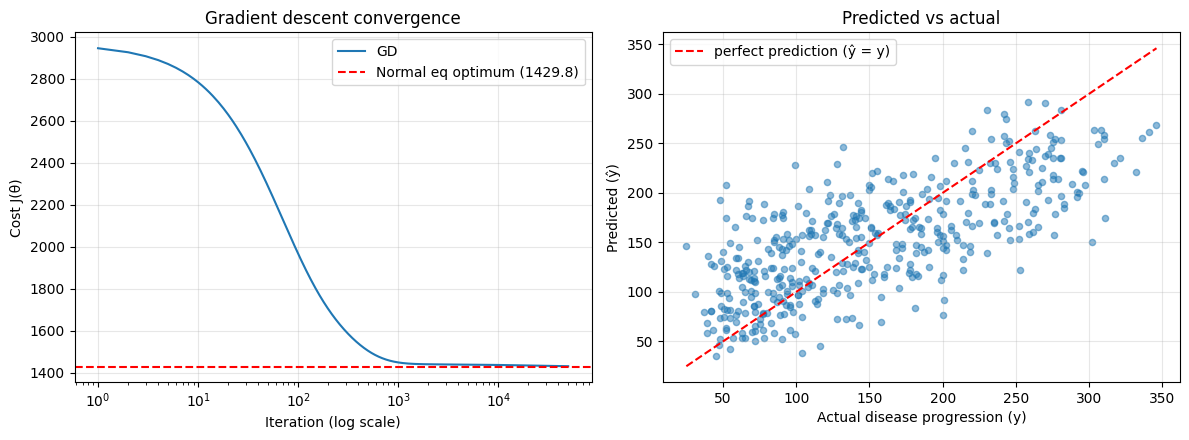

R² on training data: 0.5177    (sklearn would compute the same number)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Plot 1: cost vs iterations -----------------------------------------------
axes[0].plot(np.arange(1, len(cost_history_gd) + 1), cost_history_gd, label='GD')
axes[0].axhline(cost_ne, color='red', linestyle='--', label=f'Normal eq optimum ({cost_ne:.1f})')
axes[0].set_xscale('log')
axes[0].set_xlabel('Iteration (log scale)')
axes[0].set_ylabel('Cost J(θ)')
axes[0].set_title('Gradient descent convergence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: predicted vs actual ----------------------------------------------
y_pred = predict(X, theta_ne)            # use the exact closed-form fit
axes[1].scatter(y, y_pred, alpha=0.5, s=20)
lo, hi = y.min(), y.max()
axes[1].plot([lo, hi], [lo, hi], 'r--', label='perfect prediction (ŷ = y)')
axes[1].set_xlabel('Actual disease progression (y)')
axes[1].set_ylabel('Predicted (ŷ)')
axes[1].set_title('Predicted vs actual')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('day1_plots.png', dpi=120, bbox_inches='tight')
plt.show()

# Quick numerical summary of fit quality
ss_res = ((y - y_pred) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
r2     = 1 - ss_res / ss_tot
print(f'R² on training data: {r2:.4f}    (sklearn would compute the same number)')